<a href="https://colab.research.google.com/github/SiraajR/ML-in-Cybr_Security/blob/main/Final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn tqdm

In [4]:
!gdown https://drive.google.com/file/d/1KEd2zX_S0Q9W8Epxd244oDoQNWJuk_U1/view?usp=sharing --fuzzy

Downloading...
From (original): https://drive.google.com/uc?id=1KEd2zX_S0Q9W8Epxd244oDoQNWJuk_U1
From (redirected): https://drive.google.com/uc?id=1KEd2zX_S0Q9W8Epxd244oDoQNWJuk_U1&confirm=t&uuid=dfc0852c-cb0e-4460-b10b-b940da429d67
To: /content/MachineLearningCSV.zip
100% 235M/235M [00:03<00:00, 67.8MB/s]


In [5]:
!unzip MachineLearningCSV.zip

Archive:  MachineLearningCSV.zip
   creating: MachineLearningCVE/
  inflating: MachineLearningCVE/Wednesday-workingHours.pcap_ISCX.csv  
  inflating: MachineLearningCVE/Tuesday-WorkingHours.pcap_ISCX.csv  
  inflating: MachineLearningCVE/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv  
  inflating: MachineLearningCVE/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv  
  inflating: MachineLearningCVE/Monday-WorkingHours.pcap_ISCX.csv  
  inflating: MachineLearningCVE/Friday-WorkingHours-Morning.pcap_ISCX.csv  
  inflating: MachineLearningCVE/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv  
  inflating: MachineLearningCVE/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv  


In [6]:
import os
os.listdir("MachineLearningCVE")

['Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
 'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
 'Friday-WorkingHours-Morning.pcap_ISCX.csv',
 'Wednesday-workingHours.pcap_ISCX.csv',
 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
 'Monday-WorkingHours.pcap_ISCX.csv',
 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
 'Tuesday-WorkingHours.pcap_ISCX.csv']

In [7]:
import pandas as pd
import glob

files = glob.glob("MachineLearningCVE/*.csv")
print("Total number of files" , len(files))

dfs = []

for file in files:
  df = pd.read_csv(file)
  dfs.append(df)

data = pd.concat(dfs)
print(df.shape)

Total number of files 8
(445909, 79)


In [8]:
data.columns = data.columns.str.strip()

data = data.replace([float('inf') , -float('inf')] , pd.NA)

data = data.dropna()
data = data.drop_duplicates()

drop_cols = [
    "Flow ID",
    "Source IP",
    "Destination IP",
    "Timestamp"
]

data = data.drop(columns=[c for c in drop_cols if c in data.columns])

data["Label"] = data["Label"].apply(lambda x : 0 if x == "BENIGN" else 1)
print(data["Label"].value_counts())

Label
0    2095057
1     425741
Name: count, dtype: int64


In [9]:
x = data.drop("Label" ,axis=1)
y = data["Label"]
x = x.select_dtypes(include=["float64" , "int64"])


In [ ]:
print("Label in X:", "Label" in x.columns)

Label in X: False


In [10]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
import numpy as np


X_train , X_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model = LogisticRegression(max_iter=1000)


print("Model training")
model.fit(X_train , y_train)
prediction = model.predict(X_test)
print("classification report" , classification_report(y_test , prediction))

Model training
classification report               precision    recall  f1-score   support

           0       0.97      0.98      0.97    419342
           1       0.88      0.86      0.87     84818

    accuracy                           0.96    504160
   macro avg       0.93      0.92      0.92    504160
weighted avg       0.96      0.96      0.96    504160



In [11]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, prediction)

TN, FP, FN, TP = cm.ravel()

FPR = FP / (FP + TN)

print("False Positive Rate:", FPR)

False Positive Rate: 0.02386596143481931


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(n_estimators=30,max_depth=12 , n_jobs=1, random_state=42)
print("Random Forest training")
rf.fit(X_train, y_train)
print("Prediction begins ")
rf_pred = rf.predict(X_test)
print("classification report" , classification_report(y_test , rf_pred))


Random Forest training


In [ ]:
rf_conf = confusion_matrix(y_test, rf_pred)

TN, FP, FN, TP = rf_conf.ravel()

FPR = FP / (FP + TN)

print("False Positive Rate:", FPR)

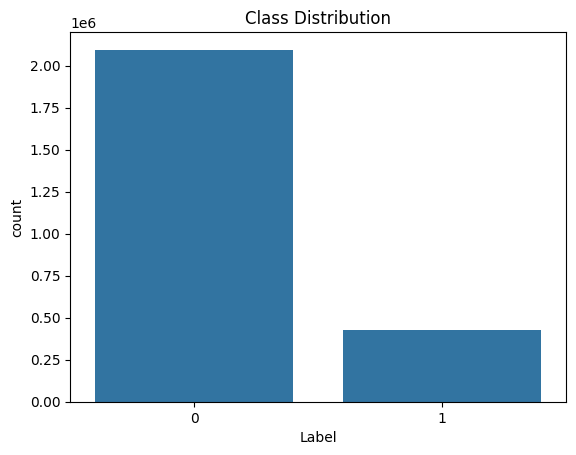

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y)
plt.title("Class Distribution")
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
